In [1]:
import matplotlib.pyplot as plt
import numpy as np

from configs.config import HamConfig

In [5]:
from utils.io import load_pickle
file_path = '../models/'
file_name = 'active_phase_ham_params_history_20251007_124905'
history = load_pickle(file_path + file_name + '.pkl')

deltas = [p[0] for p in history['ham_params']]
hs     = [p[1] for p in history['ham_params']]

Drawing Hamiltonian parameter trajectory...


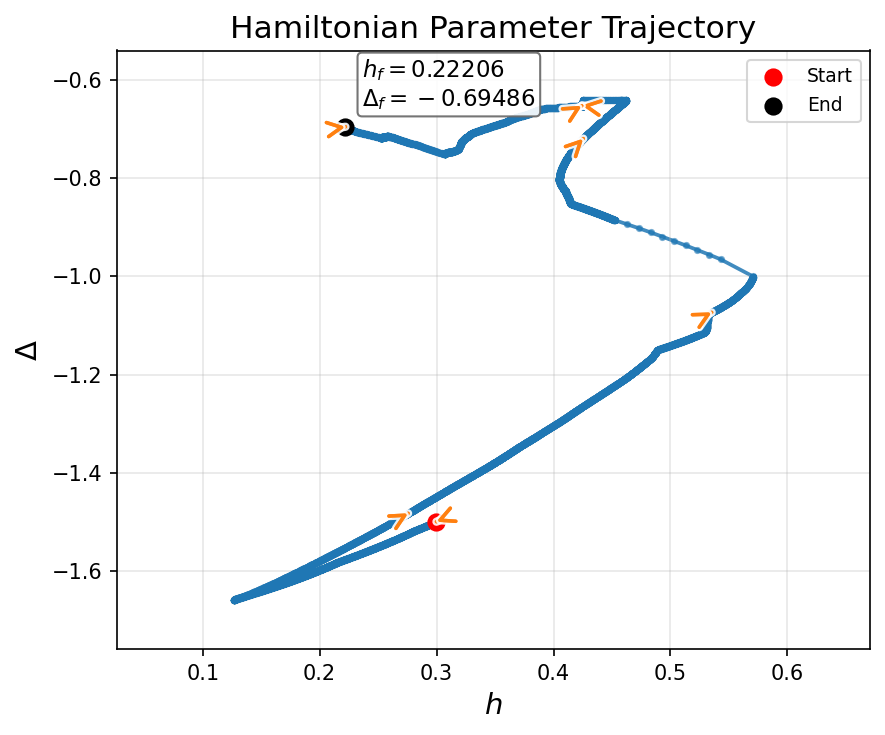

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

print('Drawing Hamiltonian parameter trajectory...')
deltas = [p[0] for p in history['ham_params']]
hs     = [p[1] for p in history['ham_params']]

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# main trajectory
ax.plot(hs, deltas, '-', color='tab:blue', lw=1.8, alpha=0.85, zorder=1)
ax.scatter(hs, deltas, s=6, color='tab:blue', alpha=0.6, zorder=2)

# start/end markers
ax.scatter(hs[0], deltas[0], s=60, color='red',   zorder=3, label='Start')
ax.scatter(hs[-1], deltas[-1], s=60, color='black', zorder=3, label='End')

# choose ~N arrows spaced along the path
N_arrows = 12
stride = max(1, (len(deltas) - 1) // N_arrows)

arrow_pe = [pe.withStroke(linewidth=4, foreground='white'), pe.Normal()]

for i in np.linspace(0, len(deltas) - 2, 7, dtype=int):
    ann = ax.annotate(
        '',
        xy=(hs[i + 1], deltas[i + 1]),       # (x, y) = (h, Δ)
        xytext=(hs[i],   deltas[i]),
        arrowprops=dict(
            arrowstyle='->',                # nice, solid arrow head
            mutation_scale=17,               # head size
            lw=1.7,
            color='#FF7F0E',
            shrinkA=0, shrinkB=0,
            alpha=0.9,
        ),
        zorder=4,
    )
    # outline the arrow so it stands out
    ann.arrow_patch.set_path_effects(arrow_pe)

hx, dx = hs[-1], deltas[-1]
label = rf"$h_f={hx:.5f}$" + "\n" + rf"$\Delta_f={dx:.5f}$"
ax.annotate(
    label,
    xy=(hx, dx), xycoords='data',
    xytext=(8, 10), textcoords='offset points',  # pixel offset to avoid overlap
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.4', alpha=0.9),
)

ax.set_xlabel(r"$h$", fontsize=14)
ax.set_ylabel(r"$\Delta$", fontsize=14)
ax.set_xlim(min(hs) - 0.1, max(hs) + 0.1)
ax.set_ylim(min(deltas) - 0.1, max(deltas) + 0.1)
ax.set_title("Hamiltonian Parameter Trajectory", fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/'+file_name+'.pdf', bbox_inches='tight', dpi=300)
# plt.show()


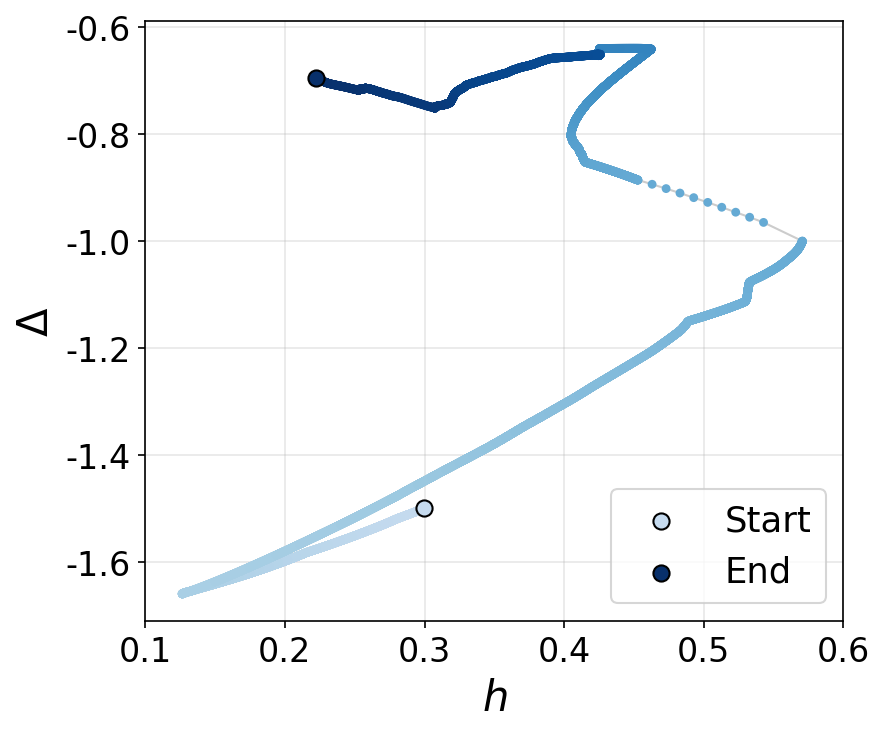

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# assume you already have lists/arrays:
# deltas = [p[0] for p in history['ham_params']]
# hs     = [p[1] for p in history['ham_params']]

n = len(hs)
order = np.arange(n)                  # 0 ... n-1 (time)

fig, ax = plt.subplots(figsize=(6,5), dpi=150)

# light-to-dark shades of one hue (same color, different shade)
cmap = plt.cm.Blues                   # try 'Greys', 'Oranges', etc. too
shades = cmap(np.linspace(0.25, 1.0, n))  # start light, end dark

# optional: faint line to show trajectory
ax.plot(hs, deltas, lw=1.0, color='0.5', alpha=0.4, zorder=1)

# points colored by shade
ax.scatter(hs, deltas, c=shades, s=18, edgecolors='none', zorder=2)

# emphasize start/end
ax.scatter(hs[0],   deltas[0],   s=60, color=shades[0],   edgecolors='k', zorder=3, label="Start")
ax.scatter(hs[-1],  deltas[-1],  s=60, color=shades[-1],  edgecolors='k', zorder=3, label="End")

ax.set_xlabel(r"$h$", fontsize=20)
ax.set_ylabel(r"$\Delta$", fontsize=20)
ax.set_yticks([-1.6, -1.4, -1.2, -1.0, -0.8, -0.6])
ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax.set_xticklabels([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], fontsize=16)
ax.set_yticklabels([-1.6, -1.4, -1.2, -1.0, -0.8, -0.6], fontsize=16)
# ax.set_title("Hamiltonian Parameter Trajectory (Color by Time)", fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=17)
plt.tight_layout()
plt.savefig('../figures/'+file_name+'.pdf', bbox_inches='tight')
